# 1D CNN with SincNet for ECG Classification (0.8-10 Hz, 4 Filters)

Notebook ini berisi implementasi lengkap 1D CNN menggunakan SincNet layer dengan 4 bandpass filters yang diinisialisasi pada rentang frekuensi 0.8-10 Hz untuk klasifikasi data ECG.

## Pipeline:
1. **Import Libraries & Setup**
2. **Model Architecture (SincNet with 4 Filters)**
3. **Data Preparation**
4. **Training**
5. **Comprehensive Evaluation & Metrics**
6. **Advanced Visualization & Analysis**
7. **Filter Analysis & Interpretation**

## 1. Import Libraries & Setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, f1_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

import math
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Set device
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")

# Set plot style
plt.style.use('default')
sns.set_palette("husl")

Using device: mps


## 2. Model Architecture - SincNet

In [2]:
class SincConv1d(nn.Module):
    """
    SincNet Convolutional Layer
    Learns bandpass filters directly in the frequency domain
    Initialized with 4 filters in the 0.8-10 Hz range
    """
    def __init__(self, out_channels=4, kernel_size=252, sample_rate=200):
        super().__init__()
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.sample_rate = sample_rate
        
        # Frequency range: 0.8 - 10 Hz (clinically relevant for ECG)
        self.min_freq = 0.8
        self.max_freq = 10.0
        
        # Initialize 4 learnable frequency parameters in 0.8-10 Hz range
        # Distribute filters evenly across the frequency range
        low_hz = np.linspace(self.min_freq, 7.0, out_channels)
        high_hz = low_hz + 2.5  # Initial bandwidth of 2.5 Hz
        
        # Ensure high_hz doesn't exceed max_freq
        high_hz = np.minimum(high_hz, self.max_freq)
        
        self.low_hz_ = nn.Parameter(torch.Tensor(low_hz))
        self.band_hz_ = nn.Parameter(torch.Tensor(high_hz - low_hz))
        
        # Time axis for filter
        n = torch.arange(-(kernel_size // 2), (kernel_size // 2) + 1)
        self.register_buffer("n", n)
    
    def forward(self, x):
        # Clamp frequencies to valid range (0.8-10 Hz)
        low = self.min_freq + torch.abs(self.low_hz_)
        high = torch.clamp(low + torch.abs(self.band_hz_), 
                          self.min_freq, self.max_freq)
        band = (high - low)[:, None]
        
        # Create bandpass filters using sinc function
        f_t_low = 2 * math.pi * low[:, None] * self.n / self.sample_rate
        f_t_high = 2 * math.pi * high[:, None] * self.n / self.sample_rate
        
        filters = (torch.sin(f_t_high) - torch.sin(f_t_low)) / (self.n / self.sample_rate + 1e-8)
        filters = filters / (2 * band)
        
        # Apply Hamming window
        filters = filters * torch.hamming_window(self.kernel_size + 1).to(x.device)
        filters = filters.unsqueeze(1)
        
        return F.conv1d(x, filters, stride=1, padding=self.kernel_size // 2)


class SincNetECG(nn.Module):
    """
    1D CNN with SincNet for ECG Classification
    Uses 4 bandpass filters in 0.8-10 Hz range
    """
    def __init__(self, sample_rate=200, num_classes=2):
        super().__init__()
        
        # SincNet layer - 4 learnable bandpass filters (0.8-10 Hz)
        self.sinc = SincConv1d(out_channels=4, kernel_size=252, sample_rate=sample_rate)
        
        # Pooling
        self.pool1 = nn.MaxPool1d(4)
        
        # Additional convolutional layers
        self.conv2 = nn.Conv1d(4, 32, kernel_size=5, padding=2)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(4)
        
        self.conv3 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn3 = nn.BatchNorm1d(64)
        self.pool3 = nn.MaxPool1d(4)
        
        # Global Average Pooling
        self.gap = nn.AdaptiveAvgPool1d(1)
        
        # Fully connected layers
        self.fc1 = nn.Linear(64, 32)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(32, num_classes)
    
    def forward(self, x):
        # SincNet layer
        x = torch.relu(self.sinc(x))
        x = self.pool1(x)
        
        # Conv block 2
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)
        
        # Conv block 3
        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)
        
        # Global pooling and classification
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Create model instance
model = SincNetECG(sample_rate=200, num_classes=2).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"\nSincNet Configuration:")
print(f"  - Number of filters: 4")
print(f"  - Frequency range: 0.8-10 Hz")
print(f"  - Kernel size: 252")
print(f"  - Sample rate: 200 Hz")

SincNetECG(
  (sinc): SincConv1d()
  (pool1): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(4, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  (gap): AdaptiveAvgPool1d(output_size=1)
  (fc1): Linear(in_features=64, out_features=32, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=32, out_features=2, bias=True)
)

Total parameters: 13,322

SincNet Configuration:
  - Number of filters: 4
  - Frequency range: 0.8-10 Hz
  - Kernel size: 252
  - Sample rate: 200 Hz


### Initial Filter Configuration

Before training, let's examine the initial frequency band configuration:

Initial Frequency Bands (Before Training):
Filter     Low (Hz)     High (Hz)    Bandwidth (Hz) 
------------------------------------------------------------
Filter 0         1.60         4.10            2.50
Filter 1         3.67         6.17            2.50
Filter 2         5.73         8.23            2.50
Filter 3         7.80        10.00            2.20


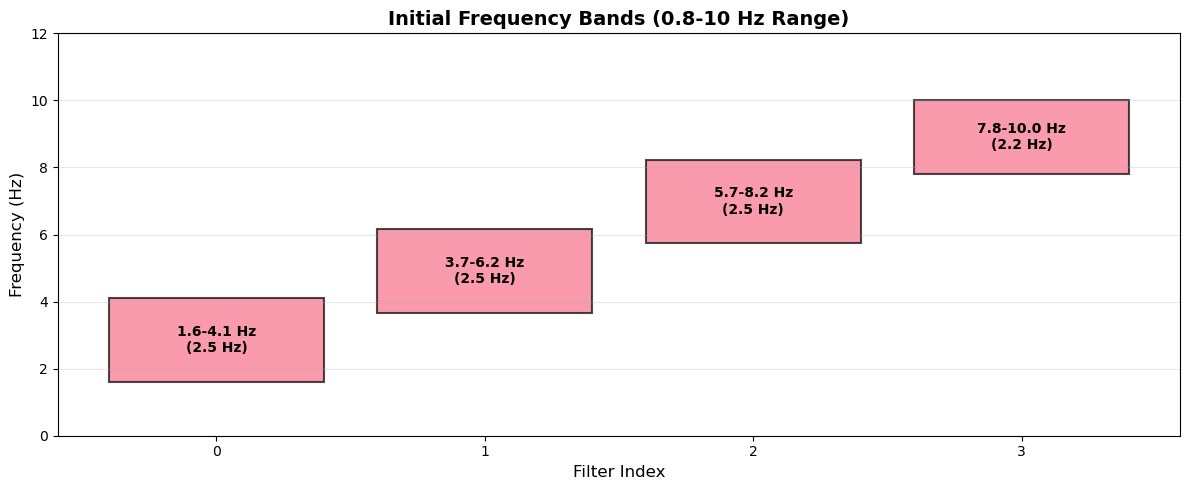

In [3]:
# Visualize initial frequency bands before training
sinc_layer = model.sinc

low_hz_init = sinc_layer.min_freq + torch.abs(sinc_layer.low_hz_).detach().cpu().numpy()
high_hz_init = low_hz_init + torch.abs(sinc_layer.band_hz_).detach().cpu().numpy()
high_hz_init = np.clip(high_hz_init, sinc_layer.min_freq, sinc_layer.max_freq)

print("Initial Frequency Bands (Before Training):")
print("=" * 60)
print(f"{'Filter':<10} {'Low (Hz)':<12} {'High (Hz)':<12} {'Bandwidth (Hz)':<15}")
print("-" * 60)
for i in range(len(low_hz_init)):
    bandwidth = high_hz_init[i] - low_hz_init[i]
    print(f"Filter {i:<3} {low_hz_init[i]:>10.2f}   {high_hz_init[i]:>10.2f}   {bandwidth:>13.2f}")
print("=" * 60)

# Plot initial frequency bands
plt.figure(figsize=(12, 5))
x = np.arange(len(low_hz_init))
plt.bar(x, high_hz_init - low_hz_init, bottom=low_hz_init, alpha=0.7, edgecolor='black', linewidth=1.5)
for i in range(len(low_hz_init)):
    plt.text(i, (low_hz_init[i] + high_hz_init[i])/2, 
             f'{low_hz_init[i]:.1f}-{high_hz_init[i]:.1f} Hz\n({high_hz_init[i]-low_hz_init[i]:.1f} Hz)', 
             ha='center', va='center', fontsize=10, fontweight='bold')
plt.xlabel('Filter Index', fontsize=12)
plt.ylabel('Frequency (Hz)', fontsize=12)
plt.title('Initial Frequency Bands (0.8-10 Hz Range)', fontsize=14, fontweight='bold')
plt.xticks(x)
plt.ylim(0, 12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 3. Data Preparation

In [4]:
class ECGDataset(Dataset):
    """
    Custom Dataset for ECG data
    """
    def __init__(self, data_dir='segmented_npy'):
        self.data_dir = data_dir
        self.file_list = [f for f in os.listdir(data_dir) if f.endswith('.npy')]
        
        print(f"Found {len(self.file_list)} files in {data_dir}")
        
    def __len__(self):
        return len(self.file_list)
    
    def __getitem__(self, idx):
        filename = self.file_list[idx]
        filepath = os.path.join(self.data_dir, filename)
        
        # Load data
        data = np.load(filepath)
        
        # Extract label from filename (e.g., s1_0001_label0.npy -> label 0)
        label = int(filename.split('_label')[-1].split('.')[0])
        
        # Convert to tensor and add channel dimension
        data = torch.FloatTensor(data).unsqueeze(0)  # Shape: (1, length)
        label = torch.LongTensor([label])[0]
        
        return data, label

# Create dataset
dataset = ECGDataset('segmented_npy')
print(f"Dataset size: {len(dataset)}")

# Check data shape
sample_data, sample_label = dataset[0]
print(f"Sample data shape: {sample_data.shape}")
print(f"Sample label: {sample_label}")

# Count labels
labels = []
for i in range(len(dataset)):
    _, label = dataset[i]
    labels.append(label.item())

unique, counts = np.unique(labels, return_counts=True)
print(f"\nLabel distribution:")
for u, c in zip(unique, counts):
    print(f"  Label {u}: {c} samples ({c/len(labels)*100:.1f}%)")

Found 80493 files in segmented_npy
Dataset size: 80493
Sample data shape: torch.Size([1, 27000])
Sample label: 0

Label distribution:
  Label 0: 45062 samples (56.0%)
  Label 1: 35431 samples (44.0%)

Label distribution:
  Label 0: 45062 samples (56.0%)
  Label 1: 35431 samples (44.0%)


In [5]:
# Split dataset into train, validation, and test sets
indices = list(range(len(dataset)))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42, stratify=labels)
train_idx, val_idx = train_test_split(train_idx, test_size=0.2, random_state=42, 
                                       stratify=[labels[i] for i in train_idx])

print(f"Training set size: {len(train_idx)}")
print(f"Validation set size: {len(val_idx)}")
print(f"Test set size: {len(test_idx)}")

# Create data loaders
batch_size = 32

train_sampler = torch.utils.data.SubsetRandomSampler(train_idx)
val_sampler = torch.utils.data.SubsetRandomSampler(val_idx)
test_sampler = torch.utils.data.SubsetRandomSampler(test_idx)

train_loader = DataLoader(dataset, batch_size=batch_size, sampler=train_sampler)
val_loader = DataLoader(dataset, batch_size=batch_size, sampler=val_sampler)
test_loader = DataLoader(dataset, batch_size=batch_size, sampler=test_sampler)

print(f"\nNumber of batches:")
print(f"  Train: {len(train_loader)}")
print(f"  Validation: {len(val_loader)}")
print(f"  Test: {len(test_loader)}")

Training set size: 51515
Validation set size: 12879
Test set size: 16099

Number of batches:
  Train: 1610
  Validation: 403
  Test: 504


## 4. Training Setup

In [6]:
# Training configuration
num_epochs = 50
learning_rate = 0.001

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Create checkpoint directory
os.makedirs('checkpoint_epoch', exist_ok=True)

print("Training configuration:")
print(f"  Epochs: {num_epochs}")
print(f"  Learning rate: {learning_rate}")
print(f"  Optimizer: Adam")
print(f"  Loss function: CrossEntropyLoss")
print(f"  Scheduler: ReduceLROnPlateau")

Training configuration:
  Epochs: 50
  Learning rate: 0.001
  Optimizer: Adam
  Loss function: CrossEntropyLoss
  Scheduler: ReduceLROnPlateau


In [7]:
# Training function
def train_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for data, labels in train_loader:
        data, labels = data.to(device), labels.to(device)
        
        # Forward pass
        optimizer.zero_grad()
        outputs = model(data)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Statistics
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc


# Validation function
def validate(model, val_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, labels in val_loader:
            data, labels = data.to(device), labels.to(device)
            
            outputs = model(data)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

print("Training and validation functions defined.")

Training and validation functions defined.


## 5. Train Model

In [8]:
# Training loop
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

best_val_acc = 0.0
best_epoch = 0

print("Starting training...")
print("=" * 70)

for epoch in range(num_epochs):
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Validate
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    # Store history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Print progress
    print(f"Epoch [{epoch+1:2d}/{num_epochs}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    
    # Save checkpoint every 5 epochs
    if (epoch + 1) % 5 == 0:
        checkpoint_path = f'checkpoint_epoch/checkpoint_epoch{epoch+1}.pt'
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_acc': val_acc
        }, checkpoint_path)
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_acc': val_acc
        }, 'checkpoint_epoch/model_best.pt')
        print(f"  → Best model saved! (Val Acc: {val_acc:.2f}%)")

print("=" * 70)
print(f"Training completed!")
print(f"Best validation accuracy: {best_val_acc:.2f}% at epoch {best_epoch}")

Starting training...
Epoch [ 1/50] | Train Loss: 0.6071 | Train Acc: 67.71% | Val Loss: 0.5502 | Val Acc: 72.54%
  → Best model saved! (Val Acc: 72.54%)
Epoch [ 1/50] | Train Loss: 0.6071 | Train Acc: 67.71% | Val Loss: 0.5502 | Val Acc: 72.54%
  → Best model saved! (Val Acc: 72.54%)
Epoch [ 2/50] | Train Loss: 0.5538 | Train Acc: 72.83% | Val Loss: 0.5333 | Val Acc: 73.14%
  → Best model saved! (Val Acc: 73.14%)
Epoch [ 2/50] | Train Loss: 0.5538 | Train Acc: 72.83% | Val Loss: 0.5333 | Val Acc: 73.14%
  → Best model saved! (Val Acc: 73.14%)
Epoch [ 3/50] | Train Loss: 0.5263 | Train Acc: 74.65% | Val Loss: 0.4943 | Val Acc: 75.98%
  → Best model saved! (Val Acc: 75.98%)
Epoch [ 3/50] | Train Loss: 0.5263 | Train Acc: 74.65% | Val Loss: 0.4943 | Val Acc: 75.98%
  → Best model saved! (Val Acc: 75.98%)
Epoch [ 4/50] | Train Loss: 0.5091 | Train Acc: 75.66% | Val Loss: 0.4786 | Val Acc: 77.00%
  → Best model saved! (Val Acc: 77.00%)
Epoch [ 4/50] | Train Loss: 0.5091 | Train Acc: 75.66% 

## 6. Comprehensive Training Visualization

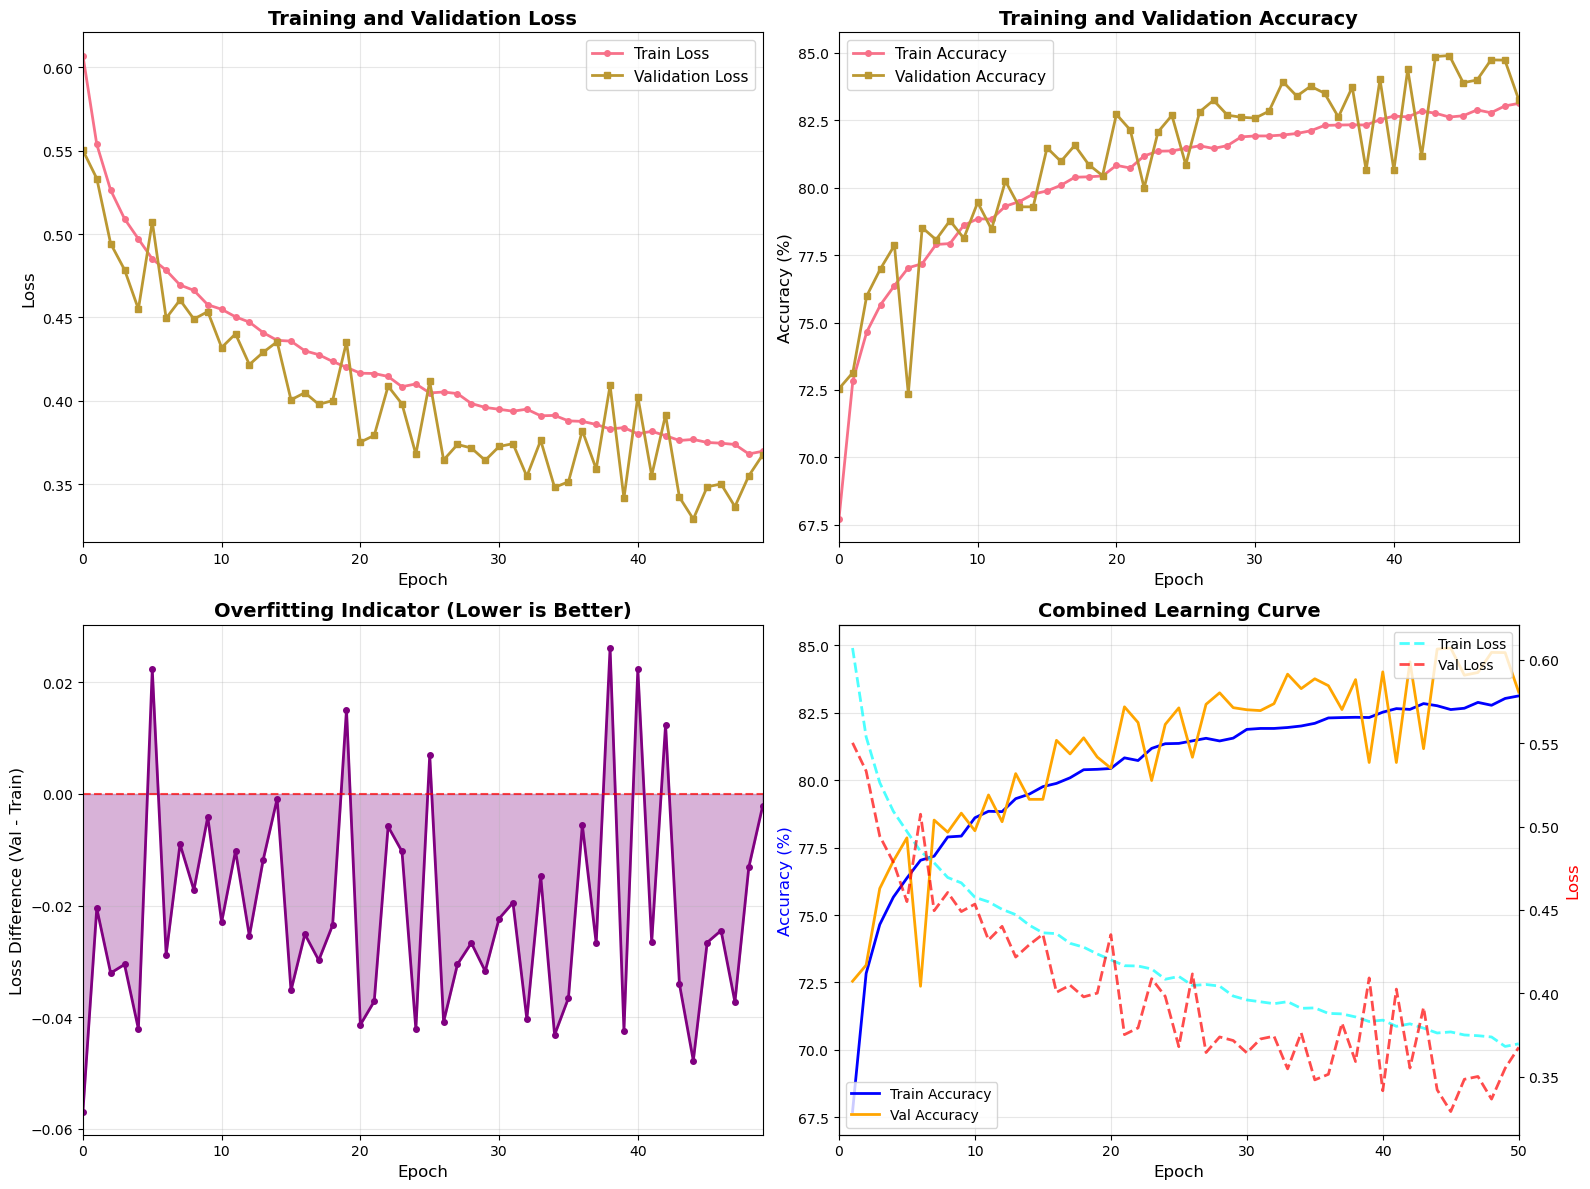


Detailed Training Summary:
Metric                         Initial         Final           Best           
--------------------------------------------------------------------------------
Train Loss                             0.6071         0.3697         0.3681
Train Accuracy                         67.71%         83.13%         83.13%
Validation Loss                        0.5502         0.3675         0.3290
Validation Accuracy                    72.54%         83.27%         84.91%

Improvement Over Training:
--------------------------------------------------------------------------------
Train Loss:        39.11% reduction
Train Accuracy:    15.42% increase
Val Loss:          33.20% reduction
Val Accuracy:      10.72% increase

Best Epoch: 45 (Val Acc: 84.91%)


In [9]:
# Comprehensive training history visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Loss plot
axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2, markersize=4)
axes[0, 0].plot(history['val_loss'], label='Validation Loss', marker='s', linewidth=2, markersize=4)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xlim(0, len(history['train_loss'])-1)

# 2. Accuracy plot
axes[0, 1].plot(history['train_acc'], label='Train Accuracy', marker='o', linewidth=2, markersize=4)
axes[0, 1].plot(history['val_acc'], label='Validation Accuracy', marker='s', linewidth=2, markersize=4)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy (%)', fontsize=12)
axes[0, 1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xlim(0, len(history['train_acc'])-1)

# 3. Loss difference (overfitting indicator)
loss_diff = np.array(history['val_loss']) - np.array(history['train_loss'])
axes[1, 0].plot(loss_diff, marker='o', linewidth=2, markersize=4, color='purple')
axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
axes[1, 0].fill_between(range(len(loss_diff)), loss_diff, 0, alpha=0.3, color='purple')
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('Loss Difference (Val - Train)', fontsize=12)
axes[1, 0].set_title('Overfitting Indicator (Lower is Better)', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xlim(0, len(loss_diff)-1)

# 4. Learning curve - both metrics
epochs = np.arange(1, len(history['train_loss']) + 1)
axes[1, 1].plot(epochs, history['train_acc'], label='Train Accuracy', linewidth=2, color='blue')
axes[1, 1].plot(epochs, history['val_acc'], label='Val Accuracy', linewidth=2, color='orange')
ax2 = axes[1, 1].twinx()
ax2.plot(epochs, history['train_loss'], label='Train Loss', linewidth=2, linestyle='--', color='cyan', alpha=0.7)
ax2.plot(epochs, history['val_loss'], label='Val Loss', linewidth=2, linestyle='--', color='red', alpha=0.7)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Accuracy (%)', fontsize=12, color='blue')
ax2.set_ylabel('Loss', fontsize=12, color='red')
axes[1, 1].set_title('Combined Learning Curve', fontsize=14, fontweight='bold')
axes[1, 1].legend(loc='lower left', fontsize=10)
ax2.legend(loc='upper right', fontsize=10)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xlim(0, len(history['train_loss']))

plt.tight_layout()
plt.show()

# Print detailed summary statistics
print(f"\nDetailed Training Summary:")
print("=" * 80)
print(f"{'Metric':<30} {'Initial':<15} {'Final':<15} {'Best':<15}")
print("-" * 80)
print(f"{'Train Loss':<30} {history['train_loss'][0]:>14.4f} {history['train_loss'][-1]:>14.4f} {min(history['train_loss']):>14.4f}")
print(f"{'Train Accuracy':<30} {history['train_acc'][0]:>13.2f}% {history['train_acc'][-1]:>13.2f}% {max(history['train_acc']):>13.2f}%")
print(f"{'Validation Loss':<30} {history['val_loss'][0]:>14.4f} {history['val_loss'][-1]:>14.4f} {min(history['val_loss']):>14.4f}")
print(f"{'Validation Accuracy':<30} {history['val_acc'][0]:>13.2f}% {history['val_acc'][-1]:>13.2f}% {max(history['val_acc']):>13.2f}%")
print("=" * 80)

# Calculate improvement metrics
train_loss_improvement = ((history['train_loss'][0] - history['train_loss'][-1]) / history['train_loss'][0]) * 100
train_acc_improvement = history['train_acc'][-1] - history['train_acc'][0]
val_loss_improvement = ((history['val_loss'][0] - history['val_loss'][-1]) / history['val_loss'][0]) * 100
val_acc_improvement = history['val_acc'][-1] - history['val_acc'][0]

print(f"\nImprovement Over Training:")
print("-" * 80)
print(f"Train Loss:       {train_loss_improvement:>6.2f}% reduction")
print(f"Train Accuracy:   {train_acc_improvement:>6.2f}% increase")
print(f"Val Loss:         {val_loss_improvement:>6.2f}% reduction")
print(f"Val Accuracy:     {val_acc_improvement:>6.2f}% increase")
print(f"\nBest Epoch: {best_epoch} (Val Acc: {best_val_acc:.2f}%)")
print("=" * 80)

## 7. Load Best Model & Evaluate

In [10]:
# Load best model
checkpoint = torch.load('checkpoint_epoch/model_best.pt')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']}")
print(f"Validation accuracy: {checkpoint['val_acc']:.2f}%")

Loaded best model from epoch 45
Validation accuracy: 84.91%


In [11]:
# Evaluate on test set
def evaluate_model(model, test_loader, device):
    model.eval()
    all_labels = []
    all_predictions = []
    all_probs = []
    
    with torch.no_grad():
        for data, labels in test_loader:
            data, labels = data.to(device), labels.to(device)
            
            outputs = model(data)
            probs = F.softmax(outputs, dim=1)
            _, predicted = torch.max(outputs, 1)
            
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    return np.array(all_labels), np.array(all_predictions), np.array(all_probs)

# Get predictions
y_true, y_pred, y_probs = evaluate_model(model, test_loader, device)

print("Test set evaluation completed.")
print(f"Total test samples: {len(y_true)}")

Test set evaluation completed.
Total test samples: 16099


## 8. Comprehensive Evaluation Metrics

In [12]:
# Calculate comprehensive metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Per-class metrics
precision_per_class = precision_score(y_true, y_pred, average=None)
recall_per_class = recall_score(y_true, y_pred, average=None)
f1_per_class = f1_score(y_true, y_pred, average=None)

print("=" * 80)
print("COMPREHENSIVE TEST SET PERFORMANCE METRICS")
print("=" * 80)
print(f"\n{'Overall Metrics:':<20}")
print(f"  Accuracy:  {accuracy*100:>6.2f}%")
print(f"  Precision: {precision:>7.4f}")
print(f"  Recall:    {recall:>7.4f}")
print(f"  F1-Score:  {f1:>7.4f}")

print("\n" + "-" * 80)
print("DETAILED CLASSIFICATION REPORT:")
print("-" * 80)
print(classification_report(y_true, y_pred, target_names=['Class 0 (Non-target)', 'Class 1 (Target)'], digits=4))

# Extended per-class analysis
print("\n" + "=" * 80)
print("PER-CLASS DETAILED ANALYSIS:")
print("=" * 80)
print(f"{'Class':<10} {'Samples':<10} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Accuracy':<10}")
print("-" * 80)
for i in range(2):
    mask = y_true == i
    if mask.sum() > 0:
        class_acc = (y_pred[mask] == i).sum() / mask.sum()
        class_name = f"Class {i}"
        print(f"{class_name:<10} {mask.sum():<10} {precision_per_class[i]:<12.4f} {recall_per_class[i]:<12.4f} {f1_per_class[i]:<12.4f} {class_acc*100:<9.2f}%")
print("=" * 80)

# Additional metrics for binary classification
if len(np.unique(y_true)) == 2:
    from sklearn.metrics import roc_auc_score, average_precision_score
    
    # Get probabilities for positive class
    y_prob_pos = y_probs[:, 1]
    
    # Calculate ROC AUC and Average Precision
    roc_auc = roc_auc_score(y_true, y_prob_pos)
    avg_precision = average_precision_score(y_true, y_prob_pos)
    
    print(f"\nAdditional Binary Classification Metrics:")
    print("-" * 80)
    print(f"  ROC AUC Score:       {roc_auc:.4f}")
    print(f"  Average Precision:   {avg_precision:.4f}")
    print("=" * 80)

COMPREHENSIVE TEST SET PERFORMANCE METRICS

Overall Metrics:    
  Accuracy:   84.51%
  Precision:  0.8449
  Recall:     0.8451
  F1-Score:   0.8448

--------------------------------------------------------------------------------
DETAILED CLASSIFICATION REPORT:
--------------------------------------------------------------------------------
                      precision    recall  f1-score   support

Class 0 (Non-target)     0.8506    0.8775    0.8639      9013
    Class 1 (Target)     0.8377    0.8040    0.8205      7086

            accuracy                         0.8451     16099
           macro avg     0.8441    0.8407    0.8422     16099
        weighted avg     0.8449    0.8451    0.8448     16099


PER-CLASS DETAILED ANALYSIS:
Class      Samples    Precision    Recall       F1-Score     Accuracy  
--------------------------------------------------------------------------------
Class 0    9013       0.8506       0.8775       0.8639       87.75    %
Class 1    7086       0.83

## 9. Advanced Confusion Matrix Analysis

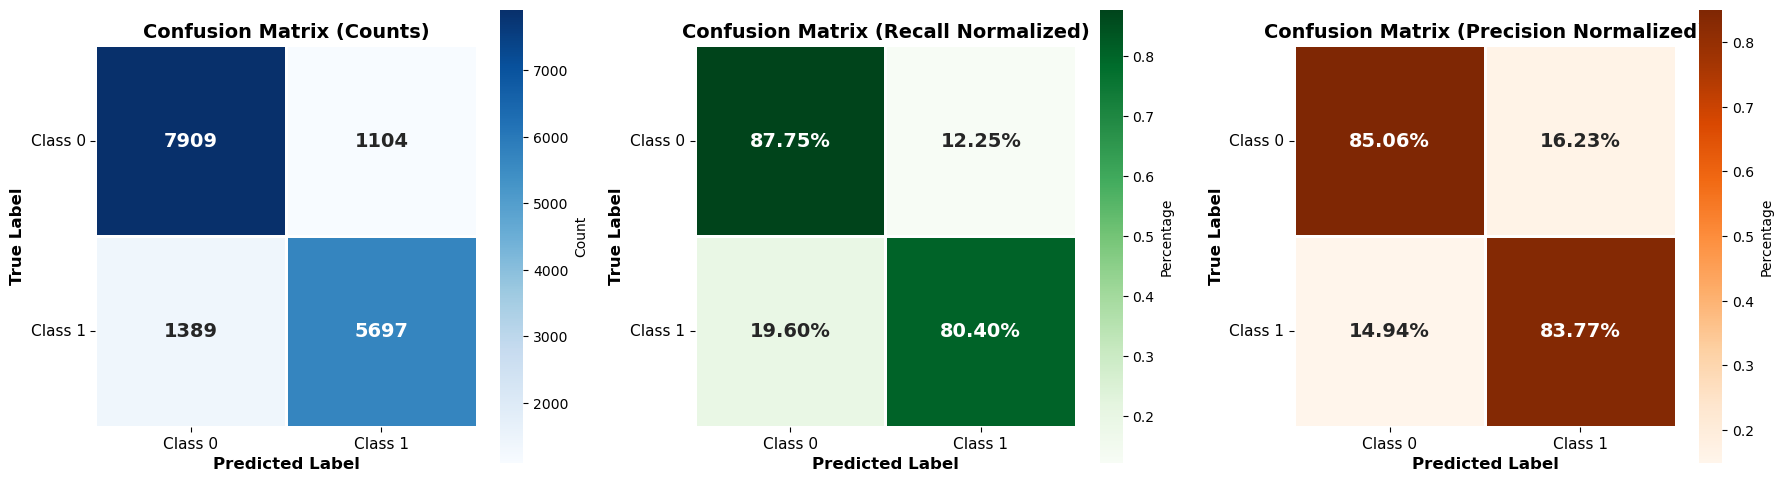


CONFUSION MATRIX DETAILED ANALYSIS

Confusion Matrix Components:
--------------------------------------------------------------------------------
  True Negatives (TN):     7909  |  False Positives (FP):    1104
  False Negatives (FN):    1389  |  True Positives (TP):     5697

Clinical/Binary Classification Metrics:
--------------------------------------------------------------------------------
  Sensitivity (TPR/Recall):         0.8040  ( 80.40%)
  Specificity (TNR):                0.8775  ( 87.75%)
  Positive Predictive Value (PPV):  0.8377  ( 83.77%)
  Negative Predictive Value (NPV):  0.8506  ( 85.06%)
  False Positive Rate (FPR):        0.1225  ( 12.25%)
  False Negative Rate (FNR):        0.1960  ( 19.60%)
  Balanced Accuracy:                0.8407  ( 84.07%)
  Matthews Correlation Coef (MCC):  0.6849

Error Analysis:
--------------------------------------------------------------------------------
  Total Errors:          2493 /  16099  ( 15.49%)
  False Positives:       1104 

In [13]:
# Confusion matrix with comprehensive analysis
cm = confusion_matrix(y_true, y_pred)

# Plot enhanced confusion matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            cbar_kws={'label': 'Count'}, square=True, linewidths=2, linecolor='white',
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xticklabels(['Class 0', 'Class 1'], fontsize=11)
axes[0].set_yticklabels(['Class 0', 'Class 1'], fontsize=11, rotation=0)

# 2. Normalized by true labels (recall perspective)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens', ax=axes[1], 
            cbar_kws={'label': 'Percentage'}, square=True, linewidths=2, linecolor='white',
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[1].set_title('Confusion Matrix (Recall Normalized)', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['Class 0', 'Class 1'], fontsize=11)
axes[1].set_yticklabels(['Class 0', 'Class 1'], fontsize=11, rotation=0)

# 3. Normalized by predictions (precision perspective)
cm_pred_norm = cm.astype('float') / cm.sum(axis=0)[np.newaxis, :]
sns.heatmap(cm_pred_norm, annot=True, fmt='.2%', cmap='Oranges', ax=axes[2], 
            cbar_kws={'label': 'Percentage'}, square=True, linewidths=2, linecolor='white',
            annot_kws={'fontsize': 14, 'fontweight': 'bold'})
axes[2].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
axes[2].set_ylabel('True Label', fontsize=12, fontweight='bold')
axes[2].set_title('Confusion Matrix (Precision Normalized)', fontsize=14, fontweight='bold')
axes[2].set_xticklabels(['Class 0', 'Class 1'], fontsize=11)
axes[2].set_yticklabels(['Class 0', 'Class 1'], fontsize=11, rotation=0)

plt.tight_layout()
plt.show()

# Comprehensive confusion matrix analysis
print("\n" + "=" * 80)
print("CONFUSION MATRIX DETAILED ANALYSIS")
print("=" * 80)

if cm.shape[0] == 2:  # Binary classification
    tn, fp, fn, tp = cm.ravel()
    
    print(f"\nConfusion Matrix Components:")
    print("-" * 80)
    print(f"  True Negatives (TN):   {tn:>6d}  |  False Positives (FP):  {fp:>6d}")
    print(f"  False Negatives (FN):  {fn:>6d}  |  True Positives (TP):   {tp:>6d}")
    
    # Calculate additional metrics
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # Recall for positive class
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # Recall for negative class
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0  # Positive Predictive Value (Precision)
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0  # Negative Predictive Value
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0  # False Negative Rate
    
    print(f"\nClinical/Binary Classification Metrics:")
    print("-" * 80)
    print(f"  Sensitivity (TPR/Recall):        {sensitivity:>7.4f}  ({sensitivity*100:>6.2f}%)")
    print(f"  Specificity (TNR):               {specificity:>7.4f}  ({specificity*100:>6.2f}%)")
    print(f"  Positive Predictive Value (PPV): {ppv:>7.4f}  ({ppv*100:>6.2f}%)")
    print(f"  Negative Predictive Value (NPV): {npv:>7.4f}  ({npv*100:>6.2f}%)")
    print(f"  False Positive Rate (FPR):       {fpr:>7.4f}  ({fpr*100:>6.2f}%)")
    print(f"  False Negative Rate (FNR):       {fnr:>7.4f}  ({fnr*100:>6.2f}%)")
    
    # Balanced accuracy
    balanced_acc = (sensitivity + specificity) / 2
    print(f"  Balanced Accuracy:               {balanced_acc:>7.4f}  ({balanced_acc*100:>6.2f}%)")
    
    # Matthews Correlation Coefficient
    mcc_num = (tp * tn) - (fp * fn)
    mcc_den = np.sqrt((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn))
    mcc = mcc_num / mcc_den if mcc_den > 0 else 0
    print(f"  Matthews Correlation Coef (MCC): {mcc:>7.4f}")
    
    print("=" * 80)
    
    # Error analysis
    total_errors = fp + fn
    total_samples = tn + fp + fn + tp
    error_rate = total_errors / total_samples
    
    print(f"\nError Analysis:")
    print("-" * 80)
    print(f"  Total Errors:        {total_errors:>6d} / {total_samples:>6d}  ({error_rate*100:>6.2f}%)")
    print(f"  False Positives:     {fp:>6d}  ({(fp/total_errors*100) if total_errors > 0 else 0:>6.2f}% of errors)")
    print(f"  False Negatives:     {fn:>6d}  ({(fn/total_errors*100) if total_errors > 0 else 0:>6.2f}% of errors)")
    print("=" * 80)

## 10. Comprehensive SincNet Filter Analysis

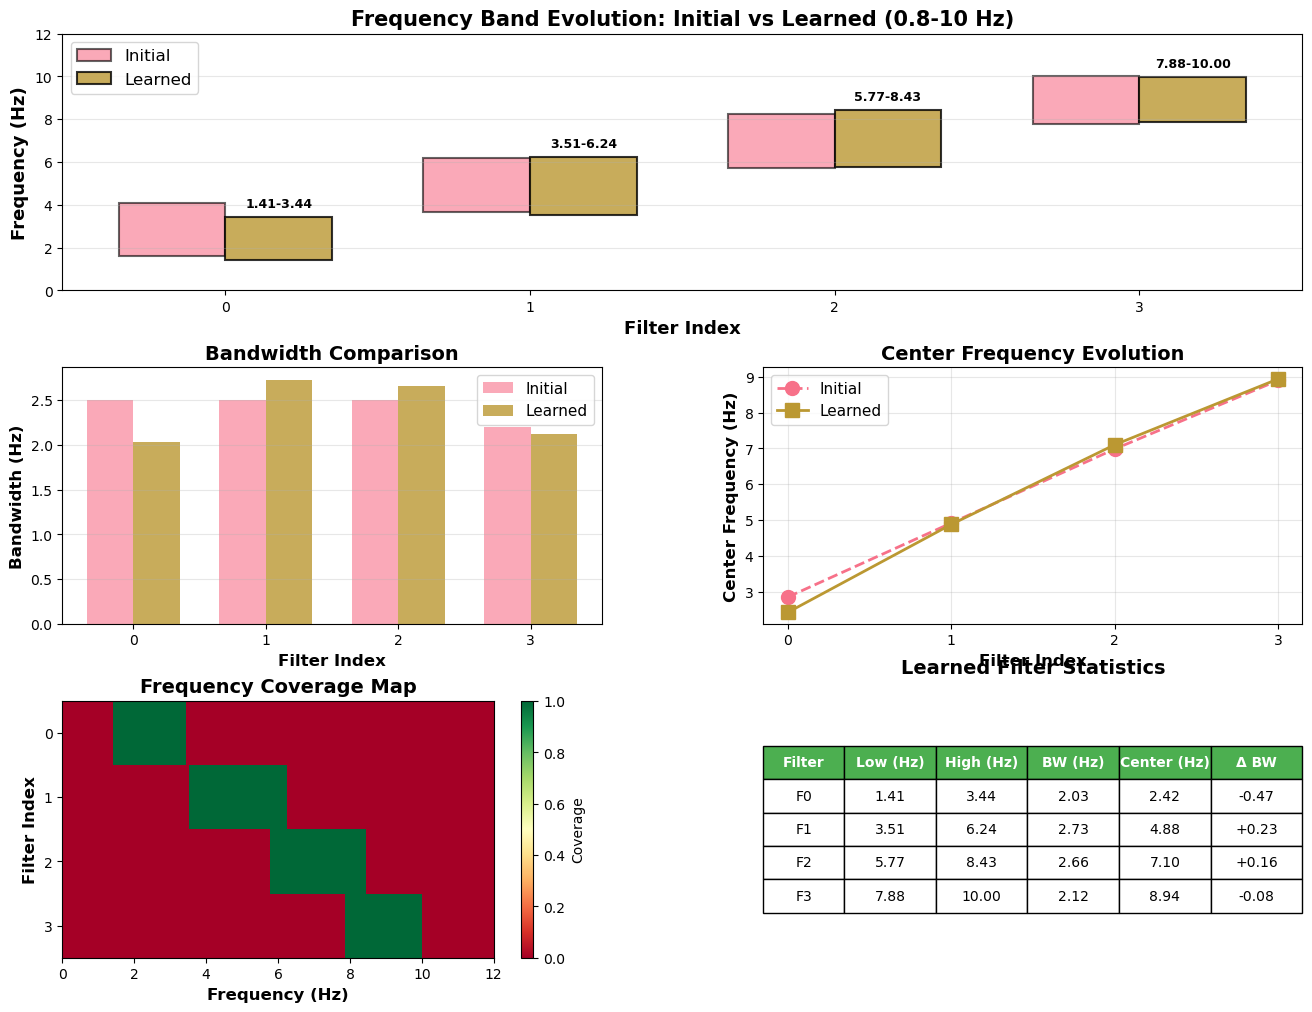


COMPREHENSIVE SINCNET FILTER ANALYSIS (4 Filters, 0.8-10 Hz Range)

Filter   Initial Low   Initial High  Initial BW    Learned Low   Learned High  Learned BW   
------------------------------------------------------------------------------------------
F0             1.600 Hz        4.100 Hz        2.500 Hz        1.406 Hz         3.437 Hz        2.032 Hz
F1             3.667 Hz        6.167 Hz        2.500 Hz        3.513 Hz         6.243 Hz        2.729 Hz
F2             5.733 Hz        8.233 Hz        2.500 Hz        5.771 Hz         8.433 Hz        2.661 Hz
F3             7.800 Hz       10.000 Hz        2.200 Hz        7.879 Hz        10.000 Hz        2.121 Hz

------------------------------------------------------------------------------------------
FREQUENCY BAND CHANGES:
------------------------------------------------------------------------------------------
Filter   Low Shift       High Shift      BW Change       Center Shift   
-----------------------------------------------

In [14]:
# Comprehensive analysis of learned frequency bands
sinc_layer = model.sinc

# Get learned frequencies
low_hz = sinc_layer.min_freq + torch.abs(sinc_layer.low_hz_).detach().cpu().numpy()
high_hz = low_hz + torch.abs(sinc_layer.band_hz_).detach().cpu().numpy()
high_hz = np.clip(high_hz, sinc_layer.min_freq, sinc_layer.max_freq)
bandwidth_hz = high_hz - low_hz
center_hz = (low_hz + high_hz) / 2

# Create comprehensive visualization
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Frequency bands comparison (Initial vs Learned)
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(len(low_hz))
width = 0.35

# Plot initial frequencies
ax1.bar(x - width/2, high_hz_init - low_hz_init, width, bottom=low_hz_init, 
        label='Initial', alpha=0.6, edgecolor='black', linewidth=1.5)
# Plot learned frequencies
ax1.bar(x + width/2, bandwidth_hz, width, bottom=low_hz, 
        label='Learned', alpha=0.8, edgecolor='black', linewidth=1.5)

ax1.set_xlabel('Filter Index', fontsize=13, fontweight='bold')
ax1.set_ylabel('Frequency (Hz)', fontsize=13, fontweight='bold')
ax1.set_title('Frequency Band Evolution: Initial vs Learned (0.8-10 Hz)', fontsize=15, fontweight='bold')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_xticks(x)
ax1.set_ylim(0, 12)

# Add annotations for learned bands
for i in range(len(low_hz)):
    ax1.text(i + width/2, high_hz[i] + 0.3, f'{low_hz[i]:.2f}-{high_hz[i]:.2f}', 
            ha='center', va='bottom', fontsize=9, fontweight='bold', rotation=0)

# 2. Bandwidth comparison
ax2 = fig.add_subplot(gs[1, 0])
bandwidth_init = high_hz_init - low_hz_init
x_pos = np.arange(len(bandwidth_hz))
bars1 = ax2.bar(x_pos - width/2, bandwidth_init, width, label='Initial', alpha=0.6)
bars2 = ax2.bar(x_pos + width/2, bandwidth_hz, width, label='Learned', alpha=0.8)
ax2.set_xlabel('Filter Index', fontsize=12, fontweight='bold')
ax2.set_ylabel('Bandwidth (Hz)', fontsize=12, fontweight='bold')
ax2.set_title('Bandwidth Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks(x_pos)

# 3. Center frequency comparison
ax3 = fig.add_subplot(gs[1, 1])
center_hz_init = (low_hz_init + high_hz_init) / 2
ax3.plot(center_hz_init, marker='o', markersize=10, label='Initial', linewidth=2, linestyle='--')
ax3.plot(center_hz, marker='s', markersize=10, label='Learned', linewidth=2)
ax3.set_xlabel('Filter Index', fontsize=12, fontweight='bold')
ax3.set_ylabel('Center Frequency (Hz)', fontsize=12, fontweight='bold')
ax3.set_title('Center Frequency Evolution', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)
ax3.set_xticks(x)

# 4. Frequency coverage heatmap
ax4 = fig.add_subplot(gs[2, 0])
freq_range = np.linspace(0, 12, 1000)
coverage = np.zeros((len(low_hz), len(freq_range)))
for i in range(len(low_hz)):
    mask = (freq_range >= low_hz[i]) & (freq_range <= high_hz[i])
    coverage[i, mask] = 1

im = ax4.imshow(coverage, aspect='auto', cmap='RdYlGn', interpolation='nearest',
                extent=[0, 12, len(low_hz)-0.5, -0.5])
ax4.set_xlabel('Frequency (Hz)', fontsize=12, fontweight='bold')
ax4.set_ylabel('Filter Index', fontsize=12, fontweight='bold')
ax4.set_title('Frequency Coverage Map', fontsize=14, fontweight='bold')
ax4.set_yticks(range(len(low_hz)))
plt.colorbar(im, ax=ax4, label='Coverage')

# 5. Filter statistics table
ax5 = fig.add_subplot(gs[2, 1])
ax5.axis('tight')
ax5.axis('off')

table_data = []
table_data.append(['Filter', 'Low (Hz)', 'High (Hz)', 'BW (Hz)', 'Center (Hz)', 'Δ BW'])
for i in range(len(low_hz)):
    bw_change = bandwidth_hz[i] - bandwidth_init[i]
    table_data.append([
        f'F{i}',
        f'{low_hz[i]:.2f}',
        f'{high_hz[i]:.2f}',
        f'{bandwidth_hz[i]:.2f}',
        f'{center_hz[i]:.2f}',
        f'{bw_change:+.2f}'
    ])

table = ax5.table(cellText=table_data, cellLoc='center', loc='center',
                  colWidths=[0.15, 0.17, 0.17, 0.17, 0.17, 0.17])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(len(table_data[0])):
    cell = table[(0, i)]
    cell.set_facecolor('#4CAF50')
    cell.set_text_props(weight='bold', color='white')

ax5.set_title('Learned Filter Statistics', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Print comprehensive analysis
print("\n" + "=" * 90)
print("COMPREHENSIVE SINCNET FILTER ANALYSIS (4 Filters, 0.8-10 Hz Range)")
print("=" * 90)

print(f"\n{'Filter':<8} {'Initial Low':<13} {'Initial High':<13} {'Initial BW':<13} "
      f"{'Learned Low':<13} {'Learned High':<13} {'Learned BW':<13}")
print("-" * 90)
for i in range(len(low_hz)):
    print(f"F{i:<7} {low_hz_init[i]:>11.3f} Hz {high_hz_init[i]:>12.3f} Hz {bandwidth_init[i]:>12.3f} Hz "
          f"{low_hz[i]:>12.3f} Hz {high_hz[i]:>13.3f} Hz {bandwidth_hz[i]:>12.3f} Hz")

print("\n" + "-" * 90)
print("FREQUENCY BAND CHANGES:")
print("-" * 90)
print(f"{'Filter':<8} {'Low Shift':<15} {'High Shift':<15} {'BW Change':<15} {'Center Shift':<15}")
print("-" * 90)
for i in range(len(low_hz)):
    low_shift = low_hz[i] - low_hz_init[i]
    high_shift = high_hz[i] - high_hz_init[i]
    bw_change = bandwidth_hz[i] - bandwidth_init[i]
    center_shift = center_hz[i] - center_hz_init[i]
    print(f"F{i:<7} {low_shift:>+13.3f} Hz {high_shift:>+13.3f} Hz {bw_change:>+13.3f} Hz {center_shift:>+13.3f} Hz")

print("\n" + "=" * 90)
print("STATISTICAL SUMMARY:")
print("-" * 90)
print(f"Average Bandwidth (Initial): {np.mean(bandwidth_init):.3f} Hz  (Std: {np.std(bandwidth_init):.3f} Hz)")
print(f"Average Bandwidth (Learned): {np.mean(bandwidth_hz):.3f} Hz  (Std: {np.std(bandwidth_hz):.3f} Hz)")
print(f"Total Frequency Coverage:    {np.sum(bandwidth_hz):.3f} Hz")
print(f"Average Center Frequency:    {np.mean(center_hz):.3f} Hz")
print(f"Frequency Range Utilized:    {np.min(low_hz):.3f} - {np.max(high_hz):.3f} Hz")
print("=" * 90)

# Clinical interpretation
print("\nCLINICAL/PHYSIOLOGICAL INTERPRETATION:")
print("-" * 90)
for i in range(len(low_hz)):
    center = center_hz[i]
    if center < 1.0:
        band_name = "Very Low Frequency (< 1 Hz)"
    elif center < 3.0:
        band_name = "Low Frequency (1-3 Hz)"
    elif center < 6.0:
        band_name = "Mid Frequency (3-6 Hz)"
    else:
        band_name = "High Frequency (6-10 Hz)"
    
    print(f"Filter {i}: {low_hz[i]:.2f}-{high_hz[i]:.2f} Hz (Center: {center:.2f} Hz)")
    print(f"  → {band_name}")
    
print("=" * 90)

### ROC Curve and Prediction Distribution Analysis

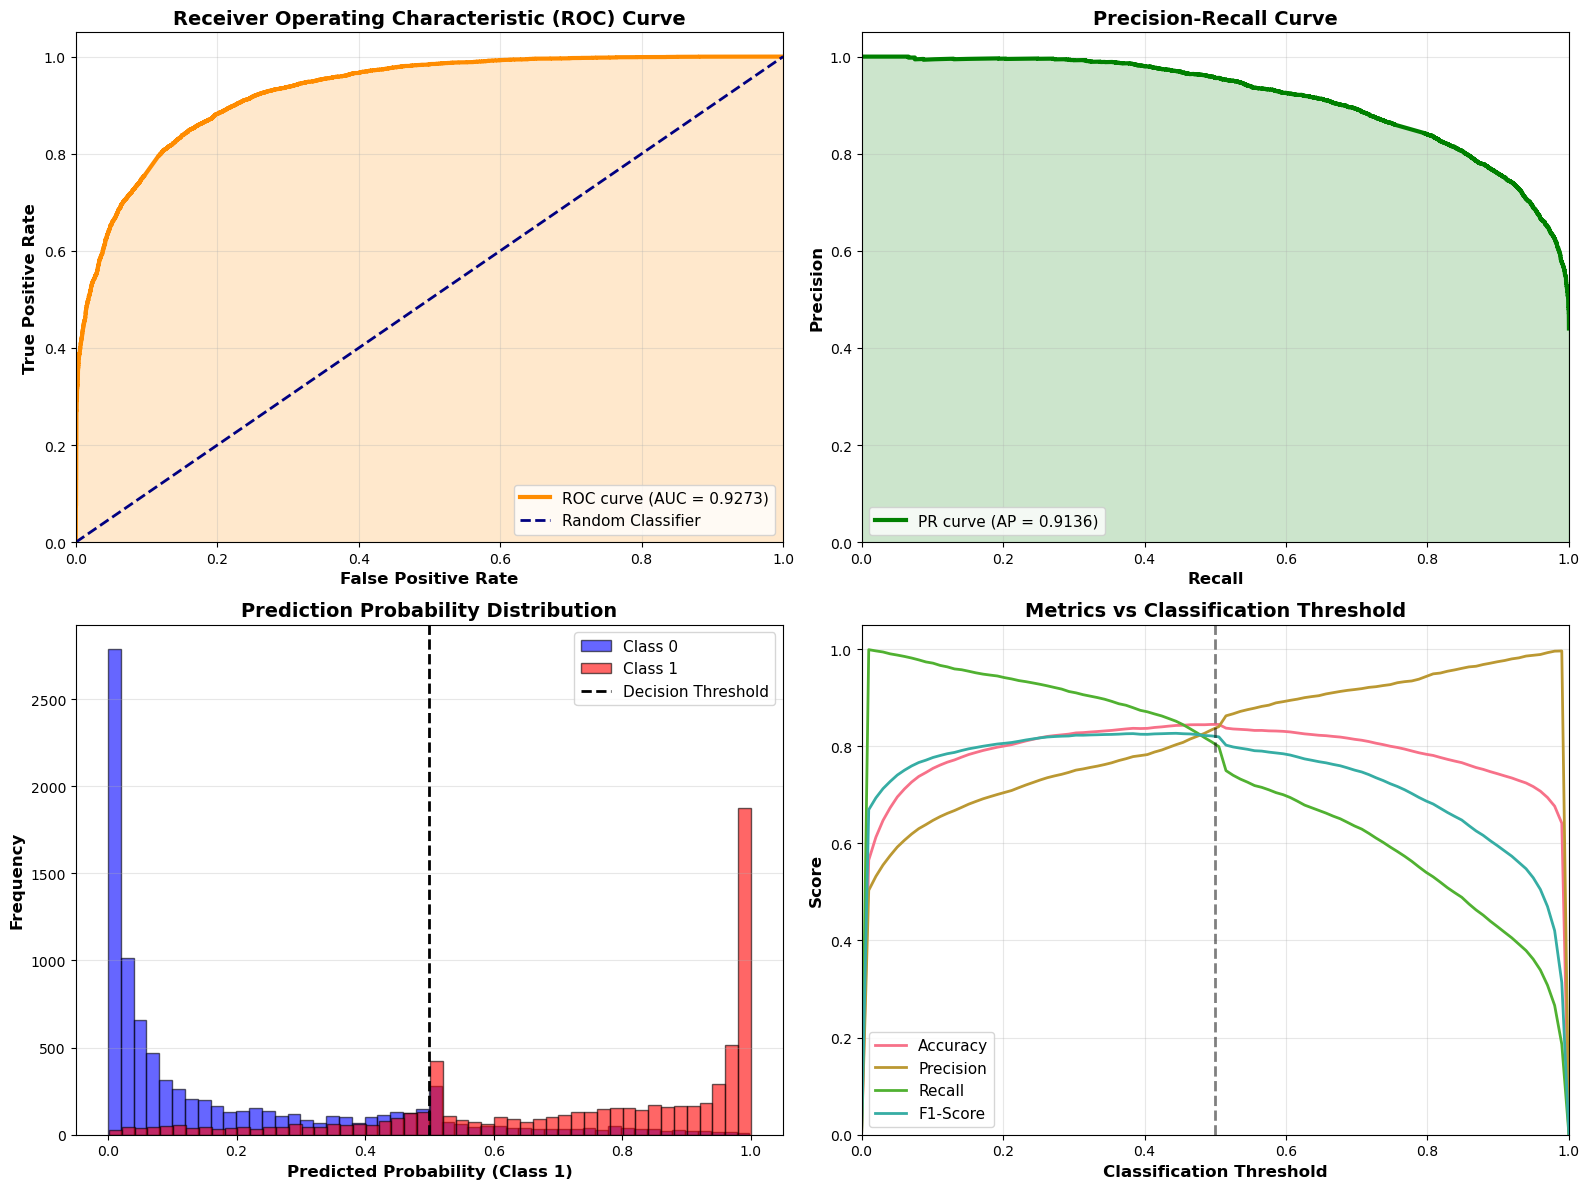


THRESHOLD ANALYSIS
Current threshold: 0.5

Optimal thresholds for different objectives:
--------------------------------------------------------------------------------
Maximum Accuracy:  Threshold = 0.495, Accuracy = 0.8450
Maximum F1-Score:  Threshold = 0.444, F1-Score = 0.8266
Maximum Precision: Threshold = 0.990, Precision = 0.9962
Maximum Recall:    Threshold = 0.010, Recall = 0.9989


In [15]:
# ROC Curve and prediction analysis
from sklearn.metrics import roc_curve, auc, precision_recall_curve

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. ROC Curve
if len(np.unique(y_true)) == 2:
    y_prob_pos = y_probs[:, 1]
    fpr, tpr, thresholds_roc = roc_curve(y_true, y_prob_pos)
    roc_auc = auc(fpr, tpr)
    
    axes[0, 0].plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.4f})')
    axes[0, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    axes[0, 0].fill_between(fpr, tpr, alpha=0.2, color='darkorange')
    axes[0, 0].set_xlim([0.0, 1.0])
    axes[0, 0].set_ylim([0.0, 1.05])
    axes[0, 0].set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    axes[0, 0].set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    axes[0, 0].set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
    axes[0, 0].legend(loc="lower right", fontsize=11)
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Precision-Recall Curve
    precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_true, y_prob_pos)
    avg_precision = average_precision_score(y_true, y_prob_pos)
    
    axes[0, 1].plot(recall_curve, precision_curve, color='green', lw=3, 
                    label=f'PR curve (AP = {avg_precision:.4f})')
    axes[0, 1].fill_between(recall_curve, precision_curve, alpha=0.2, color='green')
    axes[0, 1].set_xlim([0.0, 1.0])
    axes[0, 1].set_ylim([0.0, 1.05])
    axes[0, 1].set_xlabel('Recall', fontsize=12, fontweight='bold')
    axes[0, 1].set_ylabel('Precision', fontsize=12, fontweight='bold')
    axes[0, 1].set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
    axes[0, 1].legend(loc="lower left", fontsize=11)
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Prediction probability distribution
    axes[1, 0].hist(y_prob_pos[y_true == 0], bins=50, alpha=0.6, label='Class 0', color='blue', edgecolor='black')
    axes[1, 0].hist(y_prob_pos[y_true == 1], bins=50, alpha=0.6, label='Class 1', color='red', edgecolor='black')
    axes[1, 0].axvline(x=0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
    axes[1, 0].set_xlabel('Predicted Probability (Class 1)', fontsize=12, fontweight='bold')
    axes[1, 0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
    axes[1, 0].set_title('Prediction Probability Distribution', fontsize=14, fontweight='bold')
    axes[1, 0].legend(fontsize=11)
    axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # 4. Threshold analysis
    # Calculate metrics at different thresholds
    thresholds_test = np.linspace(0, 1, 100)
    accuracies = []
    precisions = []
    recalls = []
    f1_scores = []
    
    for thresh in thresholds_test:
        y_pred_thresh = (y_prob_pos >= thresh).astype(int)
        if len(np.unique(y_pred_thresh)) > 1:
            accuracies.append(accuracy_score(y_true, y_pred_thresh))
            precisions.append(precision_score(y_true, y_pred_thresh, zero_division=0))
            recalls.append(recall_score(y_true, y_pred_thresh, zero_division=0))
            f1_scores.append(f1_score(y_true, y_pred_thresh, zero_division=0))
        else:
            accuracies.append(0)
            precisions.append(0)
            recalls.append(0)
            f1_scores.append(0)
    
    axes[1, 1].plot(thresholds_test, accuracies, label='Accuracy', linewidth=2)
    axes[1, 1].plot(thresholds_test, precisions, label='Precision', linewidth=2)
    axes[1, 1].plot(thresholds_test, recalls, label='Recall', linewidth=2)
    axes[1, 1].plot(thresholds_test, f1_scores, label='F1-Score', linewidth=2)
    axes[1, 1].axvline(x=0.5, color='black', linestyle='--', linewidth=2, alpha=0.5)
    axes[1, 1].set_xlabel('Classification Threshold', fontsize=12, fontweight='bold')
    axes[1, 1].set_ylabel('Score', fontsize=12, fontweight='bold')
    axes[1, 1].set_title('Metrics vs Classification Threshold', fontsize=14, fontweight='bold')
    axes[1, 1].legend(fontsize=11)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_xlim([0, 1])
    axes[1, 1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

# Print threshold analysis
print("\n" + "=" * 80)
print("THRESHOLD ANALYSIS")
print("=" * 80)
print(f"Current threshold: 0.5")
print(f"\nOptimal thresholds for different objectives:")
print("-" * 80)

# Find optimal thresholds
opt_acc_idx = np.argmax(accuracies)
opt_f1_idx = np.argmax(f1_scores)
opt_prec_idx = np.argmax(precisions)
opt_recall_idx = np.argmax(recalls)

print(f"Maximum Accuracy:  Threshold = {thresholds_test[opt_acc_idx]:.3f}, Accuracy = {accuracies[opt_acc_idx]:.4f}")
print(f"Maximum F1-Score:  Threshold = {thresholds_test[opt_f1_idx]:.3f}, F1-Score = {f1_scores[opt_f1_idx]:.4f}")
print(f"Maximum Precision: Threshold = {thresholds_test[opt_prec_idx]:.3f}, Precision = {precisions[opt_prec_idx]:.4f}")
print(f"Maximum Recall:    Threshold = {thresholds_test[opt_recall_idx]:.3f}, Recall = {recalls[opt_recall_idx]:.4f}")
print("=" * 80)

## 11. Apnea Signal Example & SincNet View
Visualize a representative apnea event, compare raw signal with SincNet filter responses before vs after training, and inspect predictions.

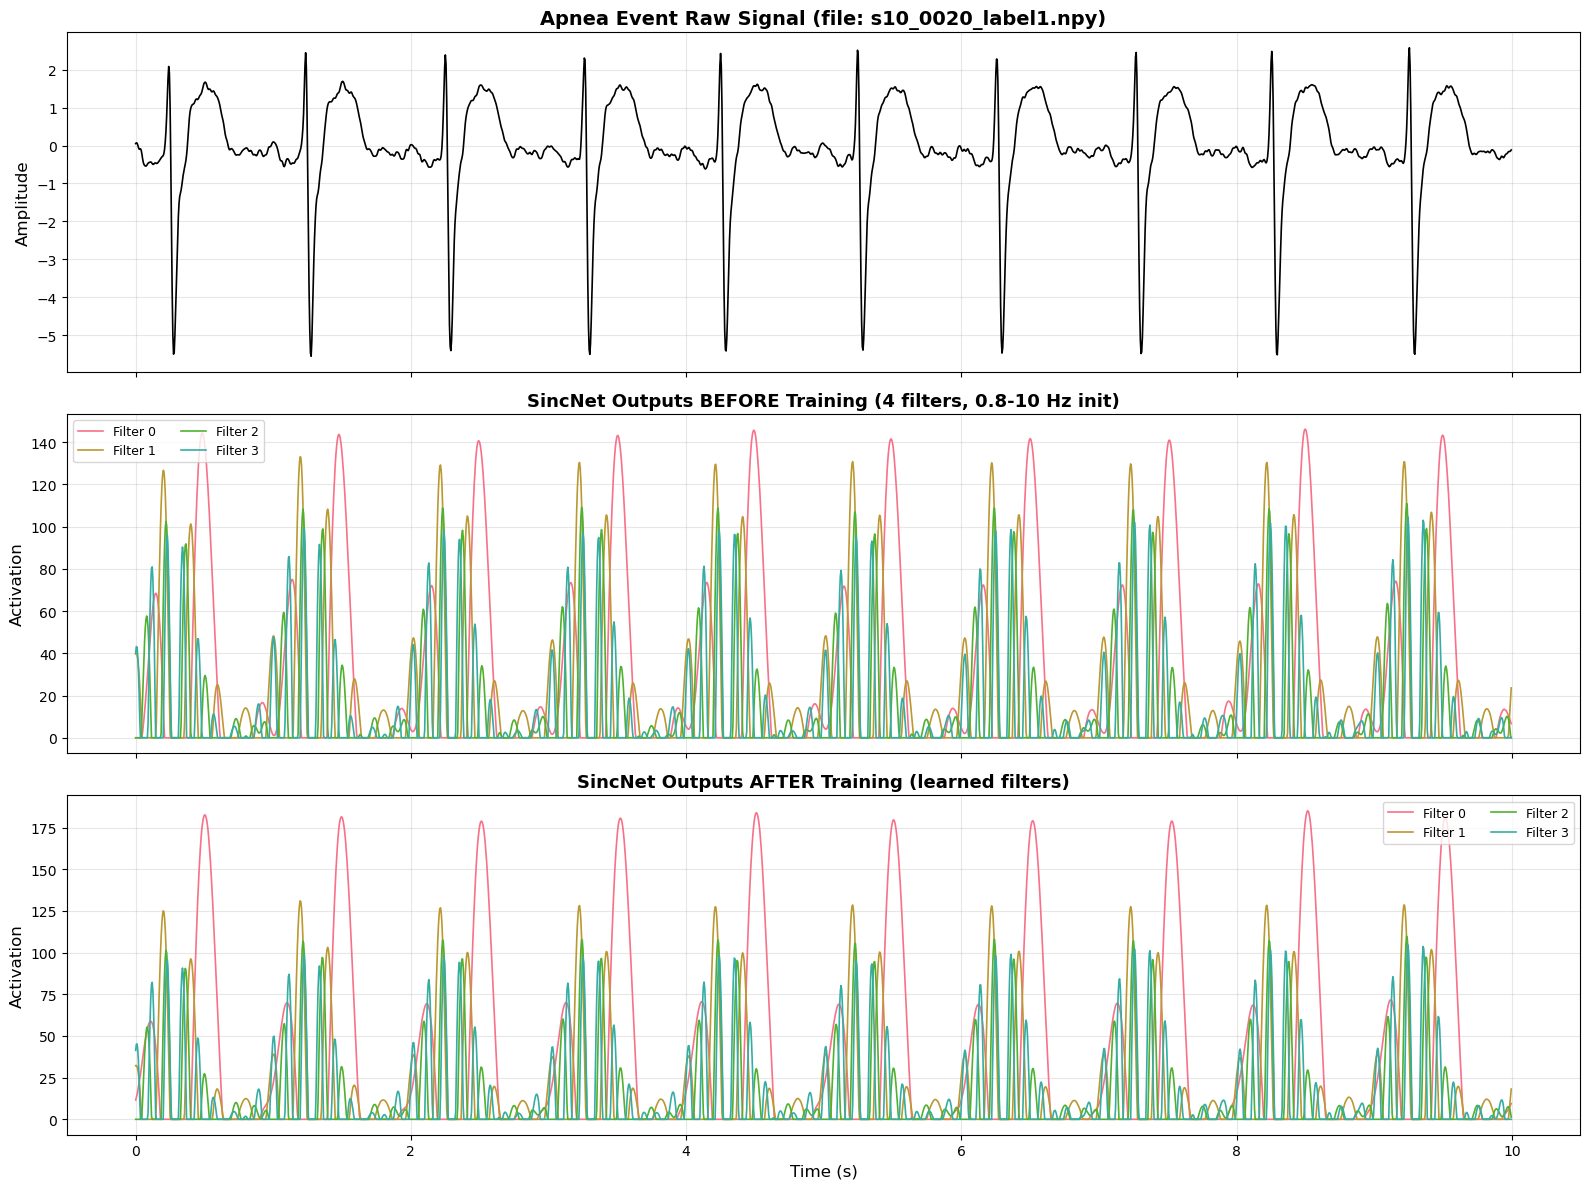

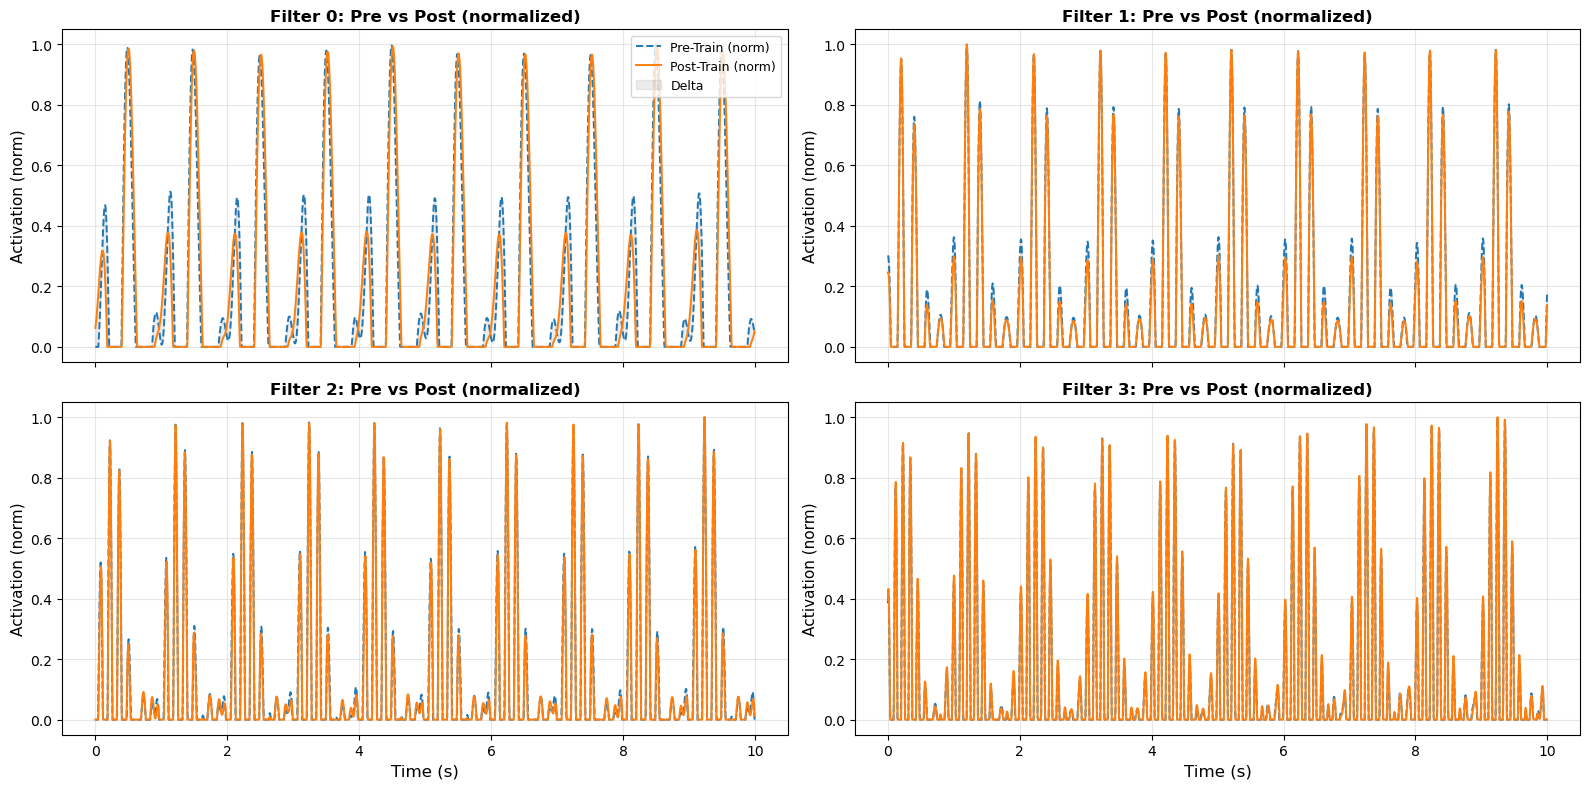

APNEA SAMPLE PREDICTION (Pre- vs Post-Training)
File: s10_0020_label1.npy
True Label: 1
Pre-Training Probabilities -> Class0: 0.1556 | Class1(apnea): 0.8444 | Pred: 1
Post-Training Probabilities -> Class0: 0.4905 | Class1(apnea): 0.5095 | Pred: 1


In [19]:
# Select an apnea example and compare SincNet outputs pre- vs post-training

# Recreate an untrained baseline with the same seed to mirror initial weights
np.random.seed(42)
torch.manual_seed(42)
model_pre = SincNetECG(sample_rate=200, num_classes=2).to(device)
model_pre.eval()
model.eval()

# Find an apnea sample (label1) deterministically
apnea_files = sorted([f for f in dataset.file_list if 'label1' in f])
if len(apnea_files) == 0:
    raise ValueError("No apnea (label1) samples found in dataset. Cannot visualize apnea example.")

apnea_file = apnea_files[0]
apnea_idx = next(i for i, f in enumerate(dataset.file_list) if f == apnea_file)

# Load apnea signal
apnea_signal, apnea_label = dataset[apnea_idx]
time_axis = np.arange(apnea_signal.shape[-1]) / 200.0  # seconds at 200 Hz

# Forward through pre- and post-training models (no grad)
with torch.no_grad():
    x = apnea_signal.unsqueeze(0).to(device)
    sinc_pre = torch.relu(model_pre.sinc(x)).cpu().numpy()[0]
    sinc_post = torch.relu(model.sinc(x)).cpu().numpy()[0]
    logits_pre = model_pre(x).cpu()
    logits_post = model(x).cpu()
    prob_pre = F.softmax(logits_pre, dim=1).numpy()[0]
    prob_post = F.softmax(logits_post, dim=1).numpy()[0]
    pred_pre = prob_pre.argmax()
    pred_post = prob_post.argmax()

# Plot raw signal and SincNet filter outputs (stacked)
plot_len = min(len(time_axis), 2000)  # show first 2000 samples (~10s)
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

axes[0].plot(time_axis[:plot_len], apnea_signal.squeeze().numpy()[:plot_len], color='black', linewidth=1.2)
axes[0].set_title(f"Apnea Event Raw Signal (file: {apnea_file})", fontsize=14, fontweight='bold')
axes[0].set_ylabel('Amplitude', fontsize=12)
axes[0].grid(True, alpha=0.3)

for i in range(sinc_pre.shape[0]):
    axes[1].plot(time_axis[:plot_len], sinc_pre[i, :plot_len], label=f'Filter {i}', linewidth=1.2)
axes[1].set_title('SincNet Outputs BEFORE Training (4 filters, 0.8-10 Hz init)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Activation', fontsize=12)
axes[1].legend(fontsize=9, ncol=2)
axes[1].grid(True, alpha=0.3)

for i in range(sinc_post.shape[0]):
    axes[2].plot(time_axis[:plot_len], sinc_post[i, :plot_len], label=f'Filter {i}', linewidth=1.2)
axes[2].set_title('SincNet Outputs AFTER Training (learned filters)', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Time (s)', fontsize=12)
axes[2].set_ylabel('Activation', fontsize=12)
axes[2].legend(fontsize=9, ncol=2)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Per-filter overlay for clearer comparison (normalized per filter)
norm_pre = sinc_pre[:, :plot_len] / (np.max(np.abs(sinc_pre[:, :plot_len]), axis=1, keepdims=True) + 1e-6)
norm_post = sinc_post[:, :plot_len] / (np.max(np.abs(sinc_post[:, :plot_len]), axis=1, keepdims=True) + 1e-6)

fig2, axes2 = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
axes2 = axes2.flatten()
for i in range(norm_pre.shape[0]):
    ax = axes2[i]
    ax.plot(time_axis[:plot_len], norm_pre[i], linestyle='--', linewidth=1.4, color='tab:blue', label='Pre-Train (norm)')
    ax.plot(time_axis[:plot_len], norm_post[i], linestyle='-', linewidth=1.4, color='tab:orange', label='Post-Train (norm)')
    ax.fill_between(time_axis[:plot_len], norm_pre[i], norm_post[i], color='gray', alpha=0.15, label='Delta' if i == 0 else None)
    ax.set_title(f'Filter {i}: Pre vs Post (normalized)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_ylabel('Activation (norm)', fontsize=11)

axes2[-1].set_xlabel('Time (s)', fontsize=12)
axes2[-2].set_xlabel('Time (s)', fontsize=12)
axes2[0].legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

# Print prediction comparison
print("=" * 80)
print("APNEA SAMPLE PREDICTION (Pre- vs Post-Training)")
print("=" * 80)
print(f"File: {apnea_file}")
print(f"True Label: {apnea_label.item()}")
print(f"Pre-Training Probabilities -> Class0: {prob_pre[0]:.4f} | Class1(apnea): {prob_pre[1]:.4f} | Pred: {pred_pre}")
print(f"Post-Training Probabilities -> Class0: {prob_post[0]:.4f} | Class1(apnea): {prob_post[1]:.4f} | Pred: {pred_post}")
print("=" * 80)

## 12. Model Architecture Analysis

In [16]:
# Analyze model architecture and layer contributions
print("=" * 90)
print("MODEL ARCHITECTURE ANALYSIS")
print("=" * 90)

# Count parameters per layer
print("\nParameter Distribution by Layer:")
print("-" * 90)
print(f"{'Layer Name':<40} {'Parameters':<15} {'Percentage':<15}")
print("-" * 90)

total_params = sum(p.numel() for p in model.parameters())
for name, param in model.named_parameters():
    param_count = param.numel()
    percentage = (param_count / total_params) * 100
    print(f"{name:<40} {param_count:>13,}  {percentage:>13.2f}%")

print("-" * 90)
print(f"{'TOTAL':<40} {total_params:>13,}  {100.0:>13.2f}%")
print("=" * 90)

# Analyze SincNet layer specifically
print("\nSincNet Layer Detailed Analysis:")
print("-" * 90)
print(f"Number of learnable filters: {model.sinc.out_channels}")
print(f"Kernel size: {model.sinc.kernel_size}")
print(f"Sample rate: {model.sinc.sample_rate} Hz")
print(f"Learnable parameters:")
print(f"  - low_hz_: {model.sinc.low_hz_.numel()} parameters")
print(f"  - band_hz_: {model.sinc.band_hz_.numel()} parameters")
print(f"  - Total SincNet learnable params: {model.sinc.low_hz_.numel() + model.sinc.band_hz_.numel()}")
print("=" * 90)

# Layer output shapes analysis
print("\nLayer Output Shape Analysis (with example input):")
print("-" * 90)
model.eval()
example_input = torch.randn(1, 1, 6000).to(device)  # Batch=1, Channel=1, Length=6000

print(f"{'Layer':<30} {'Output Shape':<25} {'# Features':<15}")
print("-" * 90)

with torch.no_grad():
    # SincNet + Pool1
    x = torch.relu(model.sinc(example_input))
    print(f"{'SincNet + ReLU':<30} {str(tuple(x.shape)):<25} {x.numel():>13,}")
    x = model.pool1(x)
    print(f"{'MaxPool1':<30} {str(tuple(x.shape)):<25} {x.numel():>13,}")
    
    # Conv2 + BN + Pool2
    x = torch.relu(model.bn2(model.conv2(x)))
    print(f"{'Conv2 + BN + ReLU':<30} {str(tuple(x.shape)):<25} {x.numel():>13,}")
    x = model.pool2(x)
    print(f"{'MaxPool2':<30} {str(tuple(x.shape)):<25} {x.numel():>13,}")
    
    # Conv3 + BN + Pool3
    x = torch.relu(model.bn3(model.conv3(x)))
    print(f"{'Conv3 + BN + ReLU':<30} {str(tuple(x.shape)):<25} {x.numel():>13,}")
    x = model.pool3(x)
    print(f"{'MaxPool3':<30} {str(tuple(x.shape)):<25} {x.numel():>13,}")
    
    # GAP
    x = model.gap(x)
    print(f"{'Global Average Pooling':<30} {str(tuple(x.shape)):<25} {x.numel():>13,}")
    x = x.view(x.size(0), -1)
    
    # FC layers
    x = torch.relu(model.fc1(x))
    print(f"{'FC1 + ReLU':<30} {str(tuple(x.shape)):<25} {x.numel():>13,}")
    x = model.fc2(x)
    print(f"{'FC2 (Output)':<30} {str(tuple(x.shape)):<25} {x.numel():>13,}")

print("=" * 90)

MODEL ARCHITECTURE ANALYSIS

Parameter Distribution by Layer:
------------------------------------------------------------------------------------------
Layer Name                               Parameters      Percentage     
------------------------------------------------------------------------------------------
sinc.low_hz_                                         4           0.03%
sinc.band_hz_                                        4           0.03%
conv2.weight                                       640           4.80%
conv2.bias                                          32           0.24%
bn2.weight                                          32           0.24%
bn2.bias                                            32           0.24%
conv3.weight                                    10,240          76.87%
conv3.bias                                          64           0.48%
bn3.weight                                          64           0.48%
bn3.bias                                    

## 13. Comprehensive Summary & Export Results

In [17]:
# Save comprehensive results to CSV files

# 1. Learned frequency bands with detailed analysis
frequency_bands_df = pd.DataFrame({
    'Filter': [f'Filter_{i}' for i in range(len(low_hz))],
    'Initial_Low_Hz': low_hz_init,
    'Initial_High_Hz': high_hz_init,
    'Initial_Bandwidth_Hz': bandwidth_init,
    'Initial_Center_Hz': center_hz_init,
    'Learned_Low_Hz': low_hz,
    'Learned_High_Hz': high_hz,
    'Learned_Bandwidth_Hz': bandwidth_hz,
    'Learned_Center_Hz': center_hz,
    'Low_Shift_Hz': low_hz - low_hz_init,
    'High_Shift_Hz': high_hz - high_hz_init,
    'Bandwidth_Change_Hz': bandwidth_hz - bandwidth_init,
    'Center_Shift_Hz': center_hz - center_hz_init
})
frequency_bands_df.to_csv('learned_frequency_bands.csv', index=False)
print("✓ Saved learned frequency bands to 'learned_frequency_bands.csv'")

# 2. Training history with additional metrics
history_df = pd.DataFrame(history)
history_df['epoch'] = range(1, len(history_df) + 1)
history_df['loss_diff'] = np.array(history['val_loss']) - np.array(history['train_loss'])
history_df['acc_diff'] = np.array(history['train_acc']) - np.array(history['val_acc'])
history_df = history_df[['epoch', 'train_loss', 'train_acc', 'val_loss', 'val_acc', 'loss_diff', 'acc_diff']]
history_df.to_csv('training_history.csv', index=False)
print("✓ Saved training history to 'training_history.csv'")

# 3. Comprehensive model results summary
results_summary = {
    'Model': 'SincNet-ECG-4Filters',
    'Frequency_Range': '0.8-10 Hz',
    'Total_Parameters': sum(p.numel() for p in model.parameters()),
    'SincNet_Filters': len(low_hz),
    'SincNet_Learnable_Params': model.sinc.low_hz_.numel() + model.sinc.band_hz_.numel(),
    'Kernel_Size': model.sinc.kernel_size,
    'Sample_Rate': model.sinc.sample_rate,
    'Num_Epochs': num_epochs,
    'Batch_Size': batch_size,
    'Learning_Rate': learning_rate,
    'Best_Epoch': best_epoch,
    'Best_Val_Acc': best_val_acc,
    'Final_Train_Loss': history['train_loss'][-1],
    'Final_Train_Acc': history['train_acc'][-1],
    'Final_Val_Loss': history['val_loss'][-1],
    'Final_Val_Acc': history['val_acc'][-1],
    'Test_Accuracy': accuracy * 100,
    'Test_Precision': precision,
    'Test_Recall': recall,
    'Test_F1': f1,
    'Train_Samples': len(train_idx),
    'Val_Samples': len(val_idx),
    'Test_Samples': len(test_idx),
}

# Add binary classification metrics if applicable
if len(np.unique(y_true)) == 2:
    results_summary['ROC_AUC'] = roc_auc_score(y_true, y_probs[:, 1])
    results_summary['Average_Precision'] = average_precision_score(y_true, y_probs[:, 1])
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    results_summary['Sensitivity'] = tp / (tp + fn)
    results_summary['Specificity'] = tn / (tn + fp)
    results_summary['True_Negatives'] = tn
    results_summary['False_Positives'] = fp
    results_summary['False_Negatives'] = fn
    results_summary['True_Positives'] = tp

results_df = pd.DataFrame([results_summary])
results_df.to_csv('model_results_summary.csv', index=False)
print("✓ Saved model results summary to 'model_results_summary.csv'")

# 4. Save detailed SincNet filter table
sincconv_filter_df = pd.DataFrame({
    'Filter_Index': range(len(low_hz)),
    'Low_Frequency_Hz': low_hz,
    'High_Frequency_Hz': high_hz,
    'Bandwidth_Hz': bandwidth_hz,
    'Center_Frequency_Hz': center_hz,
    'Low_Frequency_Init_Hz': low_hz_init,
    'High_Frequency_Init_Hz': high_hz_init,
    'Bandwidth_Init_Hz': bandwidth_init,
    'Center_Frequency_Init_Hz': center_hz_init
})
sincconv_filter_df.to_csv('sincconv_filter_table.csv', index=False)
print("✓ Saved SincConv filter details to 'sincconv_filter_table.csv'")

# 5. Save CNN architecture table
cnn_architecture_df = pd.DataFrame({
    'Layer': ['SincConv1d', 'MaxPool1', 'Conv2', 'BatchNorm2', 'MaxPool2', 
              'Conv3', 'BatchNorm3', 'MaxPool3', 'GAP', 'FC1', 'Dropout', 'FC2'],
    'Type': ['SincNet', 'Pooling', 'Conv', 'Normalization', 'Pooling',
             'Conv', 'Normalization', 'Pooling', 'Pooling', 'Linear', 'Regularization', 'Linear'],
    'Output_Channels': [4, 4, 32, 32, 32, 64, 64, 64, 64, 32, 32, 2],
    'Kernel_Size': [252, 4, 5, '-', 4, 5, '-', 4, '-', '-', '-', '-'],
    'Parameters': [
        model.sinc.low_hz_.numel() + model.sinc.band_hz_.numel(),
        0,
        sum(p.numel() for p in model.conv2.parameters()),
        sum(p.numel() for p in model.bn2.parameters()),
        0,
        sum(p.numel() for p in model.conv3.parameters()),
        sum(p.numel() for p in model.bn3.parameters()),
        0,
        0,
        sum(p.numel() for p in model.fc1.parameters()),
        0,
        sum(p.numel() for p in model.fc2.parameters())
    ]
})
cnn_architecture_df.to_csv('cnn_architecture_table.csv', index=False)
print("✓ Saved CNN architecture to 'cnn_architecture_table.csv'")

# Print final comprehensive summary
print("\n" + "=" * 90)
print("FINAL COMPREHENSIVE SUMMARY")
print("=" * 90)
print(f"\n{'MODEL CONFIGURATION:':<30}")
print(f"  Architecture:           SincNet-ECG with 4 bandpass filters")
print(f"  Frequency Range:        0.8 - 10 Hz")
print(f"  Total Parameters:       {results_summary['Total_Parameters']:,}")
print(f"  SincNet Learnable:      {results_summary['SincNet_Learnable_Params']} parameters")

print(f"\n{'TRAINING CONFIGURATION:':<30}")
print(f"  Epochs:                 {num_epochs}")
print(f"  Batch Size:             {batch_size}")
print(f"  Learning Rate:          {learning_rate}")
print(f"  Optimizer:              Adam")
print(f"  Loss Function:          CrossEntropyLoss")

print(f"\n{'DATASET SPLIT:':<30}")
print(f"  Training Samples:       {len(train_idx):,}")
print(f"  Validation Samples:     {len(val_idx):,}")
print(f"  Test Samples:           {len(test_idx):,}")
print(f"  Total Samples:          {len(dataset):,}")

print(f"\n{'TRAINING RESULTS:':<30}")
print(f"  Best Epoch:             {best_epoch}")
print(f"  Best Val Accuracy:      {best_val_acc:.2f}%")
print(f"  Final Train Loss:       {history['train_loss'][-1]:.4f}")
print(f"  Final Train Accuracy:   {history['train_acc'][-1]:.2f}%")
print(f"  Final Val Loss:         {history['val_loss'][-1]:.4f}")
print(f"  Final Val Accuracy:     {history['val_acc'][-1]:.2f}%")

print(f"\n{'TEST SET PERFORMANCE:':<30}")
print(f"  Accuracy:               {accuracy*100:.2f}%")
print(f"  Precision:              {precision:.4f}")
print(f"  Recall:                 {recall:.4f}")
print(f"  F1-Score:               {f1:.4f}")

if len(np.unique(y_true)) == 2:
    print(f"  ROC AUC:                {results_summary['ROC_AUC']:.4f}")
    print(f"  Average Precision:      {results_summary['Average_Precision']:.4f}")
    print(f"  Sensitivity:            {results_summary['Sensitivity']:.4f}")
    print(f"  Specificity:            {results_summary['Specificity']:.4f}")

print(f"\n{'LEARNED FREQUENCY BANDS:':<30}")
for i in range(len(low_hz)):
    print(f"  Filter {i}:              {low_hz[i]:.2f} - {high_hz[i]:.2f} Hz (BW: {bandwidth_hz[i]:.2f} Hz)")

print("\n" + "=" * 90)
print("✅ TRAINING, EVALUATION, AND ANALYSIS COMPLETE!")
print("=" * 90)
print("\nGenerated Files:")
print("  • learned_frequency_bands.csv")
print("  • training_history.csv")
print("  • model_results_summary.csv")
print("  • sincconv_filter_table.csv")
print("  • cnn_architecture_table.csv")
print("  • checkpoint_epoch/model_best.pt")
print("=" * 90)

✓ Saved learned frequency bands to 'learned_frequency_bands.csv'
✓ Saved training history to 'training_history.csv'
✓ Saved model results summary to 'model_results_summary.csv'
✓ Saved SincConv filter details to 'sincconv_filter_table.csv'
✓ Saved CNN architecture to 'cnn_architecture_table.csv'

FINAL COMPREHENSIVE SUMMARY

MODEL CONFIGURATION:          
  Architecture:           SincNet-ECG with 4 bandpass filters
  Frequency Range:        0.8 - 10 Hz
  Total Parameters:       13,322
  SincNet Learnable:      8 parameters

TRAINING CONFIGURATION:       
  Epochs:                 50
  Batch Size:             32
  Learning Rate:          0.001
  Optimizer:              Adam
  Loss Function:          CrossEntropyLoss

DATASET SPLIT:                
  Training Samples:       51,515
  Validation Samples:     12,879
  Test Samples:           16,099
  Total Samples:          80,493

TRAINING RESULTS:             
  Best Epoch:             45
  Best Val Accuracy:      84.91%
  Final Train Lo